# Student Attendance vs Academic Performance Analysis


- ### This project explores the relationship between student attendance and academic performance using a dataset of physics students.  
- ### We use Python (Pandas, NumPy, Matplotlib) to clean the data, visualise trends, and analyse correlations across different year groups.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## 1. Load the data

In [1]:
import pandas as pd

DATA_PATH = "attendance.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,Year,Course,attendance,Mean_Mark
0,2,Physics,15.0%,71.3
1,0,Phys and Astro (FDN),3.8%,43.0
2,2,Physics,40.7%,62.0
3,1,Physics,48.5%,10.0
4,0,Phys and Astro (FDN),30.1%,36.8
...,...,...,...,...
230,1,Physics,71.0%,62.0
231,1,Theoretical Physics,78.9%,67.8
232,0,Phys and Astro (FDN),51.9%,11.8
233,1,Physics,92.7%,86.0


The dataset was loaded using Pandas. It contains student year, course, attendance percentage, and mean marks.

## 2. Clean attendance column

In [2]:
# Use the 'replace()' function to remove '%'
df['attendance'] = df['attendance'].replace('%', '', regex=True)

# Convert the 'attendance'column to floats
df['attendance'] = df['attendance'].astype(float)

# Print the DataFrame
df





,Year,Course,attendance,Mean_Mark
0,2,Physics,15.0,71.3
1,0,Phys and Astro (FDN),3.8,43.0
2,2,Physics,40.7,62.0
3,1,Physics,48.5,10.0
4,0,Phys and Astro (FDN),30.1,36.8
...,...,...,...,...
230,1,Physics,71.0,62.0
231,1,Theoretical Physics,78.9,67.8
232,0,Phys and Astro (FDN),51.9,11.8
233,1,Physics,92.7,86.0


The attendance column was originally stored as strings with a '%' symbol.  
This was removed and the values were converted into floats to allow numerical analysis.

## 3. Scatter plot (overall trend)

<Figure size 640x480 with 0 Axes>

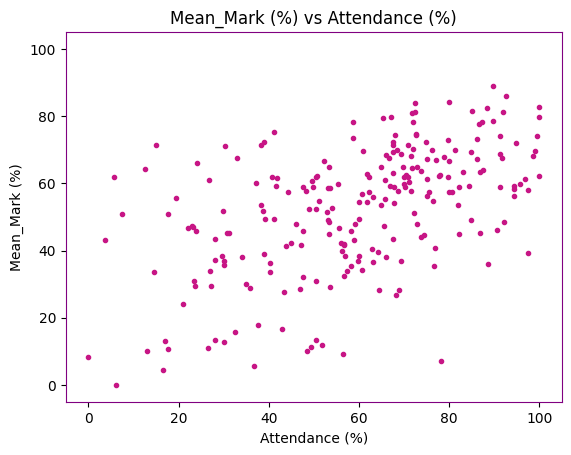

In [3]:
# Import matplotlib package
import matplotlib.pyplot as plt

# Set up plot
plt.figure()

#Set up figure and axes
fig, ax = plt.subplots()

# Plot a scatter of the mean x and y data
plt.scatter(df.attendance,df.Mean_Mark, marker=".",color="mediumvioletred")

# Label axes
plt.xlabel("Attendance (%)").set_color("k")
plt.ylabel("Mean_Mark (%)").set_color("k")

#Graph title
plt.title("Mean_Mark (%) vs Attendance (%)").set_color("k")

# Set axis limits
plt.xlim(-5, 105)
plt.ylim(-5, 105)

#Axes colour
ax.spines['left'].set_color('purple')
ax.spines['bottom'].set_color('purple')
ax.spines['right'].set_color('purple')
ax.spines['top'].set_color('purple')

plt.show()

A scatter plot was created to investigate whether there is a relationship between attendance and mean marks.

## 4. Scatter plot by year group

<Figure size 640x480 with 0 Axes>

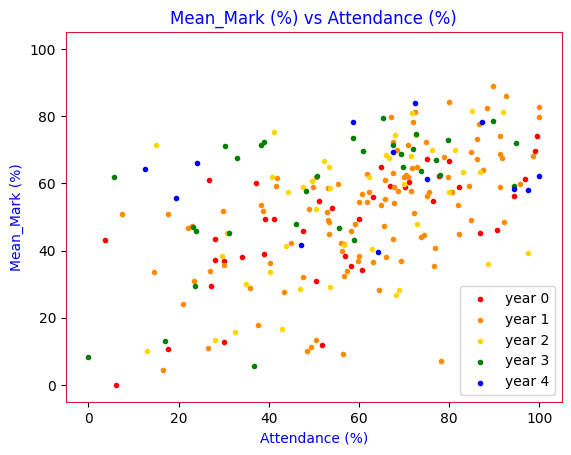

In [4]:
#Set up plot
plt.figure()

#Set up figure and axes
fig, ax = plt.subplots()

# Extract data
for year in range(5):
    mask = df.Year == year
    attendance_per_year = df.attendance[mask]
    
#Creat a loop for years and plot the scatter graph for each year
    if year == 0:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="r",label="year 0")
    elif year == 1:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="darkorange",label="year 1")
    elif year == 2:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="gold",label="year 2")
    elif year == 3:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="g",label="year 3")
    elif year == 4:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="b",label="year 4")

# Label axes
plt.xlabel("Attendance (%)").set_color("b")
plt.ylabel("Mean_Mark (%)").set_color("b")

# Graph title
plt.title("Mean_Mark (%) vs Attendance (%)").set_color("b")

# Set axis limits
plt.xlim(-5, 105)
plt.ylim(-5, 105)

#Add legends
plt.legend(loc="best")

#Axes colour
ax.spines['left'].set_color('crimson')
ax.spines['bottom'].set_color('crimson')
ax.spines['right'].set_color('crimson')
ax.spines['top'].set_color('crimson')

plt.show() 

The data was split by year group to check whether the relationship between attendance and marks changes across years.

The data was split by year group to check whether the relationship between attendance and marks changes across years.

## 5. Line of best fit (by year)


<Figure size 640x480 with 0 Axes>

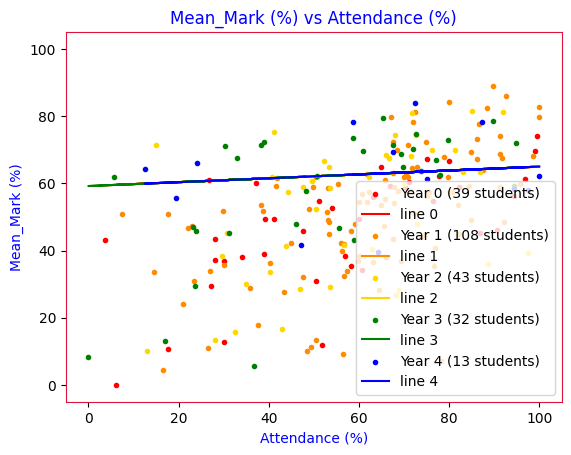

In [5]:
# Import numpy module
import numpy as np

#Set up plot
plt.figure()

# Using numpy, fit the line with a first order polynomial
coeff = np.polyfit(df.attendance[mask], df.Mean_Mark[mask], 1) 
poly_func = np.poly1d(coeff)

#Set up figure and axes
fig, ax = plt.subplots()

# Extract data
for year in range(5):
    mask = df.Year == year
    attendance_per_year = df.attendance[mask]                                   
    
#Creat a loop for years and creat scatter graph and the resulting fit for each year
    if year == 0:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="r",label=f'Year {year} ({len(df.attendance[mask])} students)')
        plt.plot(df.attendance[mask], poly_func(df.attendance[mask]), label='line 0', linestyle= '-',color="r")  
    elif year == 1:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="darkorange",label=f'Year {year} ({len(df.attendance[mask])} students)')
        plt.plot(df.attendance[mask], poly_func(df.attendance[mask]), label='line 1', linestyle= '-', color="darkorange")  
    elif year == 2:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="gold",label=f'Year {year} ({len(df.attendance[mask])} students)')
        plt.plot(df.attendance[mask], poly_func(df.attendance[mask]), label='line 2', linestyle= '-', color="gold")  
    elif year == 3:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="g",label=f'Year {year} ({len(df.attendance[mask])} students)')
        plt.plot(df.attendance[mask], poly_func(df.attendance[mask]), label='line 3', linestyle= '-', color="g")  
    elif year == 4:
        plt.scatter(df.attendance[mask], df.Mean_Mark[mask], marker=".", color="b",label=f'Year {year} ({len(df.attendance[mask])} students)')
        plt.plot(df.attendance[mask], poly_func(df.attendance[mask]), label='line 4', linestyle= '-', color="b")  

          
# Label axes
plt.xlabel("Attendance (%)").set_color("b")
plt.ylabel("Mean_Mark (%)").set_color("b")

# Graph title
plt.title("Mean_Mark (%) vs Attendance (%)").set_color("b")

# Set axis limits
plt.xlim(-5, 105)
plt.ylim(-5, 105)

#Add legends
plt.legend(loc="best")

#Axes colour
ax.spines['left'].set_color('crimson')
ax.spines['bottom'].set_color('crimson')
ax.spines['right'].set_color('crimson')
ax.spines['top'].set_color('crimson')


plt.show() 

A linear regression (first-order polynomial fit) was applied to each year group to examine trends more clearly.  
The fitted lines show whether attendance has a predictive relationship with academic performance.

### Conclusion

Overall, there is no strong correlation between attendance and mean marks in this dataset.  
The scatter plots and fitted lines show that performance does not significantly increase with higher attendance.

This trend is consistent across all year groups, suggesting that attendance alone is not a strong predictor of academic performance in this case.